In [1]:
import pandas as pd
import requests
from pathlib import Path

In [2]:
PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

compound_info = pd.read_csv(PROCESSED_DIR / "compound_information.csv")

compound_info

,compound_id,compound_name,compound_group,abbreviation,notes,CID,MolecularFormula,MolecularWeight,ConnectivitySMILES,IUPACName
0,CMP001,Epigallocatechin gallate,Catechin,EGCG,Major catechin in matcha,65064,C22H18O11,458.40,C1C(C(OC2=CC(=CC(=C21)O)O)C3=CC(=C(C(=C3)O)O)O...,"[(2R,3R)-5,7-dihydroxy-2-(3,4,5-trihydroxyphen..."
1,CMP002,Caffeine,Alkaloid,CAF,Purine alkaloid and stimulant,2519,C8H10N4O2,194.19,CN1C=NC2=C1C(=O)N(C(=O)N2C)C,"1,3,7-trimethylpurine-2,6-dione"
2,CMP003,L-theanine,Amino acid,THE,Non-protein amino acid,439378,C7H14N2O3,174.20,CCNC(=O)CCC(C(=O)O)N,(2S)-2-amino-5-(ethylamino)-5-oxopentanoic acid
3,CMP004,Epigallocatechin,Catechin,EGC,Tea catechin,72277,C15H14O7,306.27,C1C(C(OC2=CC(=CC(=C21)O)O)C3=CC(=C(C(=C3)O)O)O)O,"(2R,3R)-2-(3,4,5-trihydroxyphenyl)-3,4-dihydro..."
4,CMP005,Epicatechin gallate,Catechin,ECG,Tea catechin,107905,C22H18O10,442.40,C1C(C(OC2=CC(=CC(=C21)O)O)C3=CC(=C(C=C3)O)O)OC...,"[(2R,3R)-2-(3,4-dihydroxyphenyl)-5,7-dihydroxy..."
5,CMP006,Epicatechin,Catechin,EC,Tea catechin,72276,C15H14O6,290.27,C1C(C(OC2=CC(=CC(=C21)O)O)C3=CC(=C(C=C3)O)O)O,"(2R,3R)-2-(3,4-dihydroxyphenyl)-3,4-dihydro-2H..."
6,CMP007,Catechin,Catechin,CAT,Flavan-3-ol,9064,C15H14O6,290.27,C1C(C(OC2=CC(=CC(=C21)O)O)C3=CC(=C(C=C3)O)O)O,"(2R,3S)-2-(3,4-dihydroxyphenyl)-3,4-dihydro-2H..."
7,CMP008,Gallic acid,Phenolic acid,GA,Phenolic compound,370,C7H6O5,170.12,C1=C(C=C(C(=C1O)O)O)C(=O)O,"3,4,5-trihydroxybenzoic acid"


In [3]:
compounds = compound_info["compound_name"].tolist()

print("Compounds selected for target analysis:")

for compound in compounds:
    print("-", compound)

Compounds selected for target analysis:
- Epigallocatechin gallate
- Caffeine
- L-theanine
- Epigallocatechin
- Epicatechin gallate
- Epicatechin
- Catechin
- Gallic acid


In [4]:
compound_info.loc[0, "ConnectivitySMILES"]

'C1C(C(OC2=CC(=CC(=C21)O)O)C3=CC(=C(C(=C3)O)O)O)OC(=O)C4=CC(=C(C(=C4)O)O)O'

In [6]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd()

targets = pd.read_csv(
    PROJECT_ROOT / "data" / "external" / "SwissTargetPrediction.csv"
)

targets.head()

,Target,Common name,Uniprot ID,ChEMBL ID,Target Class,Probability*,Known actives (3D/2D)
0,Dual specificity tyrosine-phosphorylation-regu...,DYRK1A,Q13627,CHEMBL2292,Kinase,1.000000,32 / 27
1,Voltage-gated inwardly rectifying potassium ch...,KCNH2,Q12809,CHEMBL240,Voltage-gated ion channel,1.000000,1 / 75
2,Beta-secretase 1,BACE1,P56817,CHEMBL4822,Protease,1.000000,28 / 74
3,Dual specificity tyrosine-phosphorylation-regu...,DYRK1B,Q9Y463,CHEMBL5543,Kinase,0.998557,2 / 2
4,A disintegrin and metalloproteinase with throm...,ADAMTS5,Q9UNA0,CHEMBL2285,Protease,0.998557,2 / 5


In [7]:
targets.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Target                 100 non-null    str    
 1   Common name            96 non-null     str    
 2   Uniprot ID             100 non-null    str    
 3   ChEMBL ID              100 non-null    str    
 4   Target Class           100 non-null    str    
 5   Probability*           100 non-null    float64
 6   Known actives (3D/2D)  100 non-null    str    
dtypes: float64(1), str(6)
memory usage: 5.6 KB


In [9]:
targets.head(15)

,Target,Common name,Uniprot ID,ChEMBL ID,Target Class,Probability*,Known actives (3D/2D)
0,Dual specificity tyrosine-phosphorylation-regu...,DYRK1A,Q13627,CHEMBL2292,Kinase,1.000000,32 / 27
1,Voltage-gated inwardly rectifying potassium ch...,KCNH2,Q12809,CHEMBL240,Voltage-gated ion channel,1.000000,1 / 75
2,Beta-secretase 1,BACE1,P56817,CHEMBL4822,Protease,1.000000,28 / 74
3,Dual specificity tyrosine-phosphorylation-regu...,DYRK1B,Q9Y463,CHEMBL5543,Kinase,0.998557,2 / 2
4,A disintegrin and metalloproteinase with throm...,ADAMTS5,Q9UNA0,CHEMBL2285,Protease,0.998557,2 / 5
5,Dual specificity tyrosine-phosphorylation-regu...,DYRK4,Q9NR20,CHEMBL1075115,Kinase,0.998557,1 / 1
6,Dual specificity protein kinase CLK4,CLK4,Q9HAZ1,CHEMBL4203,Kinase,0.998557,2 / 1
7,Dual specificity tyrosine-phosphorylation-regu...,DYRK2,Q92630,CHEMBL4376,Kinase,0.998557,3 / 1
8,MAP kinase-activated protein kinase 5,MAPKAPK5,Q8IW41,CHEMBL3094,Kinase,0.998557,1 / 2
9,Mitogen-activated protein kinase 14,MAPK14,Q16539,CHEMBL260,Kinase,0.998557,2 / 33


In [10]:
targets["Target Class"].value_counts()

Target Class
Kinase                                     27
Protease                                   14
Lyase                                      10
Oxidoreductase                              7
Transferase                                 6
Unclassified protein                        6
Secreted protein                            4
Primary active transporter                  3
Eraser                                      3
Transcription factor                        2
Enzyme                                      2
Hydrolase                                   2
Cytochrome P450                             2
Nuclear receptor                            2
Voltage-gated ion channel                   1
Other nuclear protein                       1
Writer                                      1
Other cytosolic protein                     1
Other ion channel                           1
Membrane receptor                           1
Isomerase                                   1
Ligand-gated ion chan

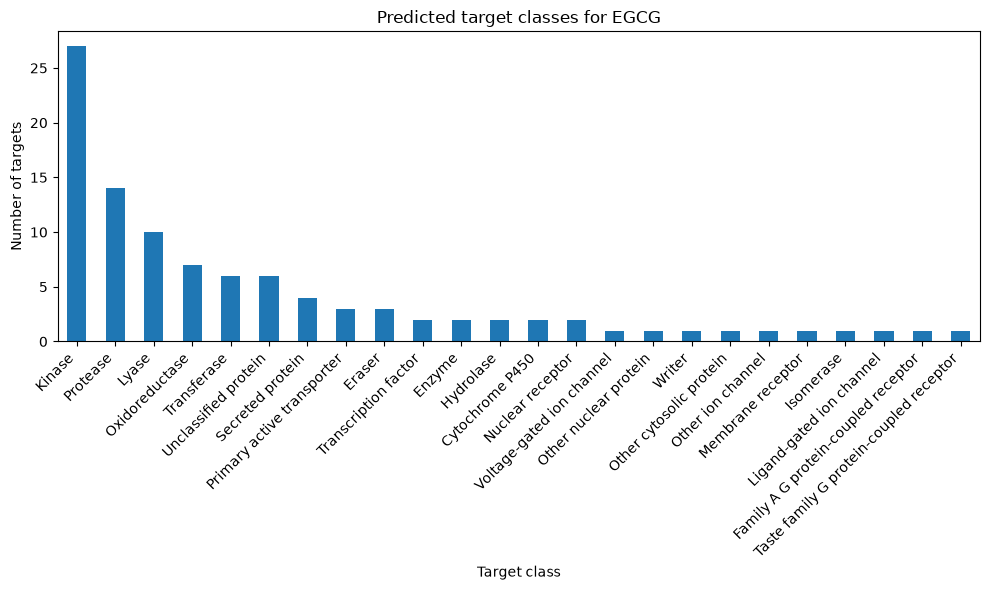

In [11]:

import matplotlib.pyplot as plt

class_counts = targets["Target Class"].value_counts()

plt.figure(figsize=(10,6))

class_counts.plot(kind="bar")

plt.title("Predicted target classes for EGCG")
plt.xlabel("Target class")
plt.ylabel("Number of targets")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

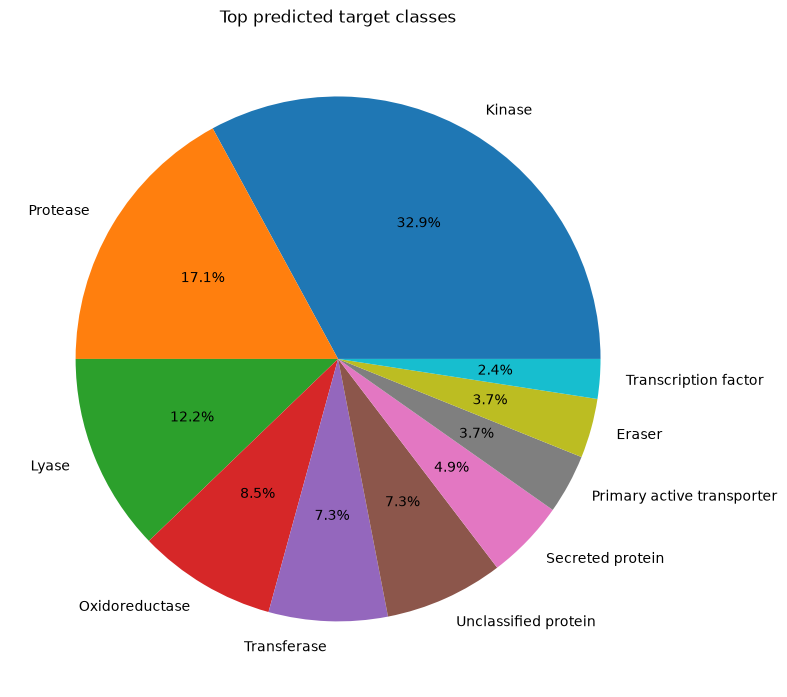

In [12]:
plt.figure(figsize=(8,8))

class_counts.head(10).plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")

plt.title("Top predicted target classes")

plt.tight_layout()

plt.show()

In [13]:
OUTPUT = PROJECT_ROOT / "outputs"

OUTPUT.mkdir(exist_ok=True)

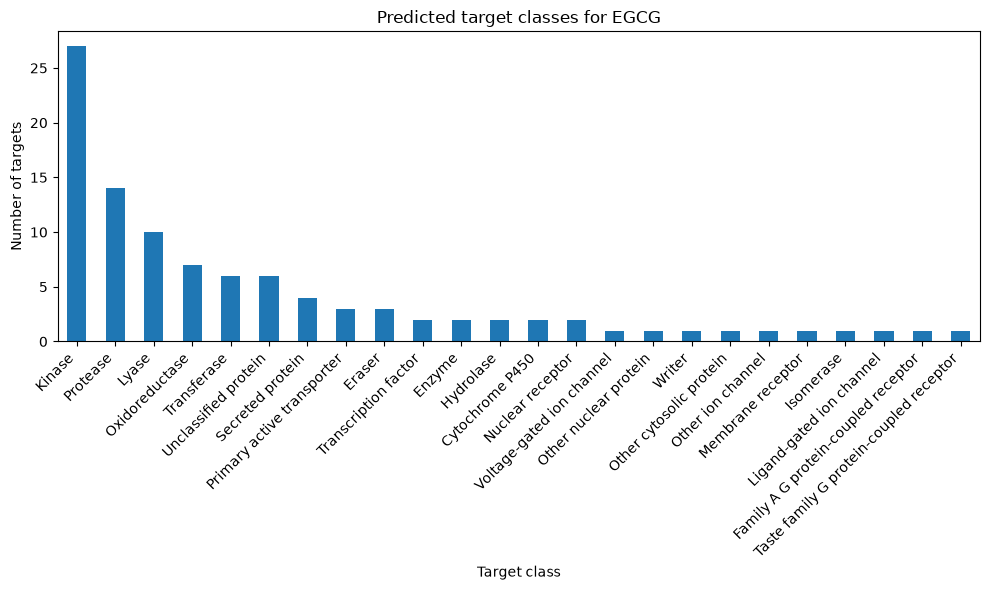

In [14]:
fig = plt.figure(figsize=(10,6))

class_counts.plot(kind="bar")

plt.title("Predicted target classes for EGCG")
plt.xlabel("Target class")
plt.ylabel("Number of targets")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

fig.savefig(
    OUTPUT / "egcg_target_classes.png",
    dpi=300,
    bbox_inches="tight"
)

In [15]:
genes = (
    targets["Common name"]
    .dropna()
    .drop_duplicates()
    .sort_values()
)

genes

32      ABCB1
69      ABCC1
68      ABCG2
98       ACHE
38    ADAMTS4
       ...   
40       TERT
36        TTR
93        TYR
86      VEGFA
60        XDH
Name: Common name, Length: 96, dtype: str

In [16]:
genes.to_csv(
    PROJECT_ROOT / "data" / "processed" / "EGCG_gene_list.csv",
    index=False,
    header=["Gene"]
)

print("Gene list saved.")

Gene list saved.


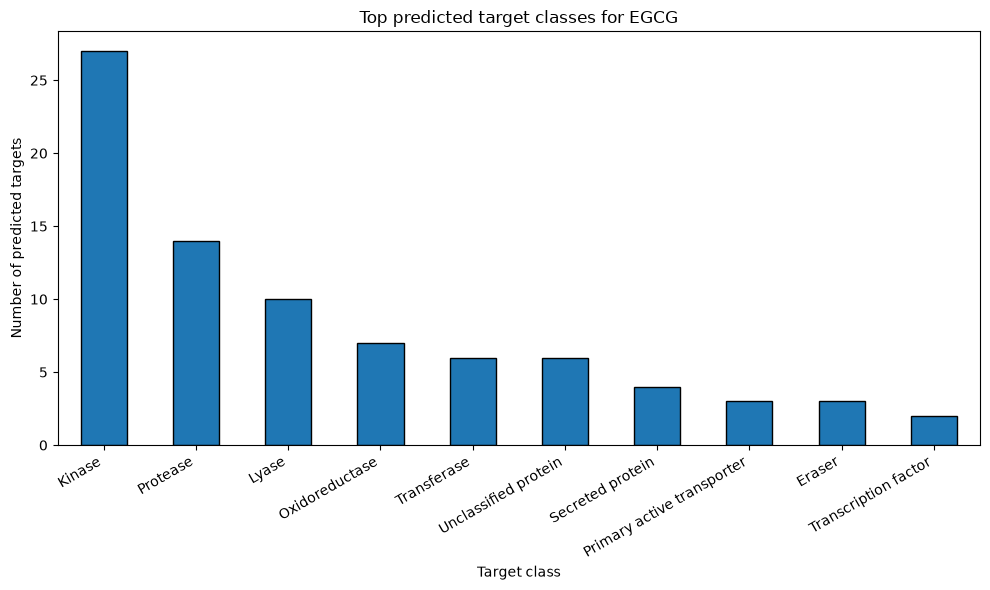

In [17]:
import matplotlib.pyplot as plt

top_classes = targets["Target Class"].value_counts().head(10)

plt.figure(figsize=(10,6))

top_classes.plot(kind="bar", edgecolor="black")

plt.title("Top predicted target classes for EGCG")
plt.xlabel("Target class")
plt.ylabel("Number of predicted targets")

plt.xticks(rotation=30, ha="right")

plt.tight_layout()

plt.show()

In [18]:
genes = (
    targets["Common name"]
    .dropna()
    .drop_duplicates()
    .sort_values()
)

genes.to_csv(
    PROJECT_ROOT / "data" / "processed" / "EGCG_gene_list.csv",
    index=False,
    header=["Gene"]
)

print("EGCG gene list saved.")

EGCG gene list saved.
